In [1]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate


In [2]:
N = 10
L= 1.0
def epsilon(i):
    return pi**2*i**2/(2*L**2)
def psi(i,x):
    return sqrt(2/L)*sin(i*pi*x/L)
def n(x, N):
    n = 0.
    for i in range(1,N+1):
        n += np.abs(psi(i,x)**2)
    return n

def Eexact(N):
    E = 0.
    for i in range(1,N+1):
        E += epsilon(i)
    return E

def E_KDF(N):
    return (pi**2/6)*integrate.quad(lambda x: n(x,N)**3, 0, L)[0]

print(E_KDF(N=2))


21.79537638573901


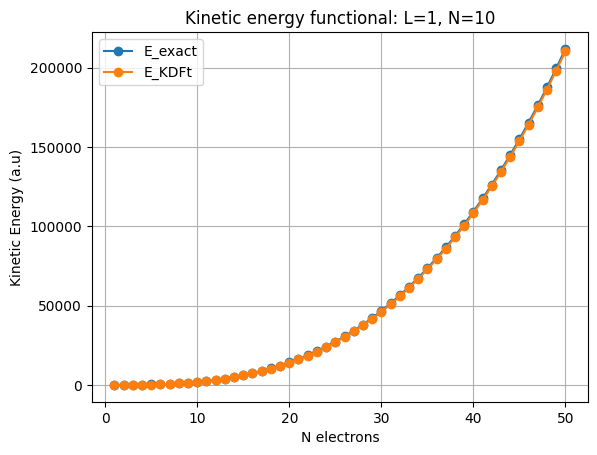

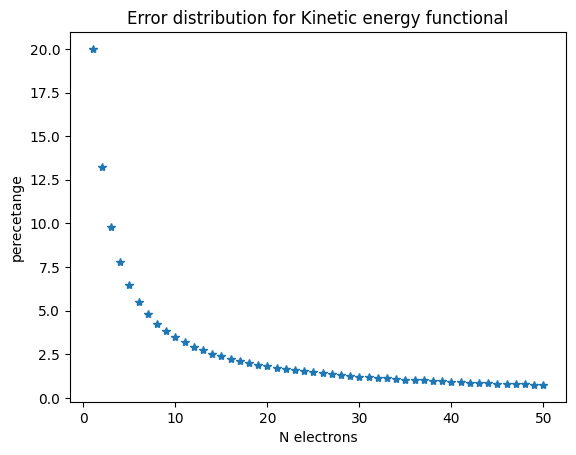

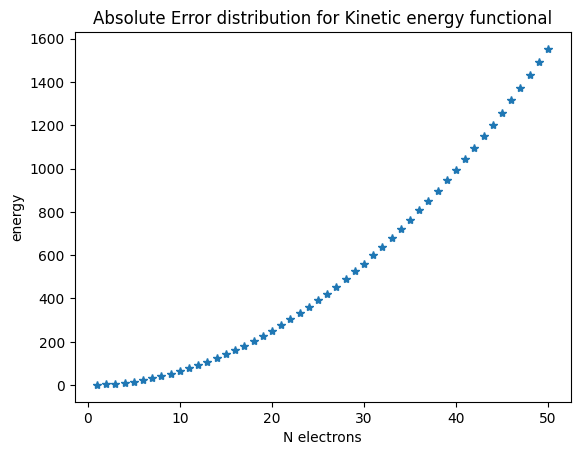

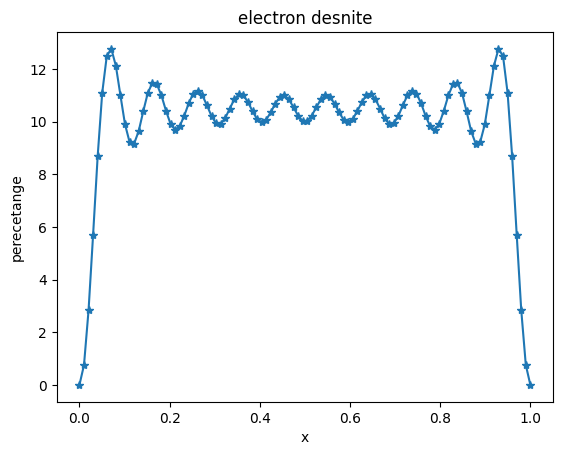

In [3]:
E_exact = []
EKDF = [] 
e_desnite =[]
for N in range (1, 51):
    E_exact.append(Eexact(N))
    EKDF.append(E_KDF(N))
E_exact= np.array(E_exact)
EKDF = np.array(EKDF)
plt.plot(range(1, N+1), E_exact, "o-", label ="E_exact")
plt.plot(range(1, N+1), EKDF, "o-", label ="E_KDFt")
plt.title("Kinetic energy functional: L=1, N=10")
plt.xlabel("N electrons")
plt.ylabel("Kinetic Energy (a.u)")
plt.grid()
plt.legend() 
plt.show()
    
relative_error = np.abs(E_exact - EKDF)*100/EKDF
absolute_error = np.abs(E_exact - EKDF)

#print(f"absolute error = {absolute_error} a.u")
#print(f"realtive error = {relative_error} %")

plt.plot(range(1, N+1), relative_error, '*')
plt.title("Error distribution for Kinetic energy functional")
plt.xlabel("N electrons")
plt.ylabel("perecetange")
#plt.legend() 
plt.show()

plt.plot(range(1, N+1),absolute_error, '*')
plt.title("Absolute Error distribution for Kinetic energy functional")
plt.xlabel("N electrons")
plt.ylabel("energy")
#plt.legend() 
plt.show()


x_array = np.linspace(0,L,100)
for x in x_array:
    e_desnite.append(n(x, 10))
plt.plot(np.linspace(0,L,100),e_desnite, '*-')
plt.title("electron desnite")
plt.xlabel("x")
plt.ylabel("perecetange")
#plt.legend() 
plt.show()

## when N electron increasres the relative error decreases